# Poisson equation in a multi-patch domain

In [1]:
%matplotlib inline

import numpy as np
import scipy
import matplotlib.pyplot as plt
import itertools

np.set_printoptions(linewidth=100000)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, adaptive
from pyiga import assemble_cy

In [2]:
# define discretization space (we may choose nested discretization spaces)
p = 3
N = 10
kvs = [2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),)]

In [3]:
# define geometry
geos = [
    geometry.quarter_annulus(),
    geometry.unit_square().translate((-1, 1)),
    geometry.quarter_annulus().rotate_2d(np.pi).translate((-1, 3)),
    geometry.quarter_annulus().rotate_2d(-np.pi/2).translate((-2, 1))
]

patches = [(kv, g) for kv,g in zip(kvs,geos)]

In [4]:
# source term f and Dirichlet boundary function g
f  = lambda x, y: np.exp(-5 * ((x-0.3)**2 + (y-1)**2))
gD = lambda x, y: 1e-1 * np.sin(8*x)

# Robin boundary data such that \partial_n u + alpha * u = g1, if alpha=0 this represents also a Neumann boundary condition.
gN = lambda x, y: 0.
alpha = lambda x, y: 0.

# set up a PatchMesh object, which detects interfaces between patches
M = topology.MultiPatch(patches)

# by default all outer boundaries are given the index 0, which we will use for the Dirichlet boundary
# let us generate a Neumann boundary indexed by 1
M.set_boundary_id({'Neumann/Robin':{(0,'left'),(2,'right'),(3,'left'),(3,'right')},
                   'Dirichlet':{(0,'bottom'),(0,'right'),(1,'top'),(2,'bottom'),(2,'left'),(3,'bottom')}})

# set up a MultiPatch object that initializes a Basis to map global dofs to local dofs
MP = assemble.MultiBasis(M)
MP.set_subspace('C0')

# set Dirichlet values for DoFs at the Dirichlet boundary
dir_bcs = MP.set_dirichlet_boundary({'Dirichlet':gD})

# assemble the linear system and (possible) Neumann vector or Robin matrix/vector
Kh = MP.assemble_volume("inner(grad(u), grad(v)) * dx", arity = 2)
Fh = MP.assemble_volume("f * v * dx", arity=1, physical=True, f=f) #f is living in the physical domain

# generate Neumann vector for global contribution to the right hand side, in this case it is a zero vector since g1 is zero
Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann/Robin')

# generate Robin Matrix for global contribution to the right hand side, in this case it is a zero matrix again since alpha is zero
Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Neumann/Robin')

setting up constraints took 0.004405498504638672 seconds.
Basis setup took 0.0017857551574707031 seconds


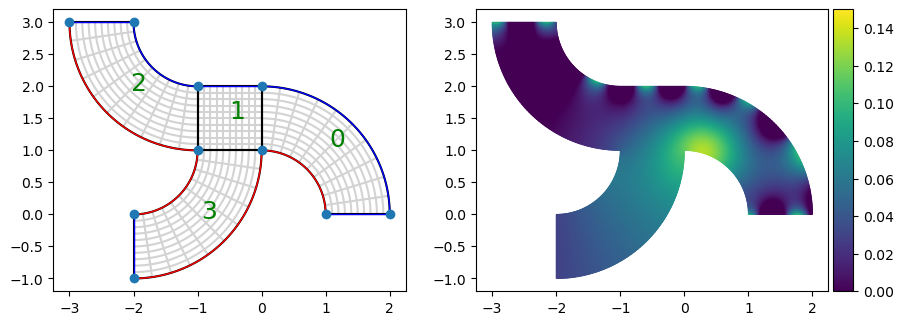

In [5]:
# set up and solve linear system by eliminating Dirichlet DoFs from the system
LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
u = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

# restrict solution to each individual patch (kvs on every patch) and visualize solution together with the mesh
fig, ax = plt.subplots(1,2,figsize=(10,5))
M.plotmesh(patch_idx = True, knots=True, nodes=True, bcolor={'Dirichlet':'blue','Neumann/Robin':'red'}, axis=ax[0])
MP.plot(u, range = (0, 1.5e-1),cbar=True, cmap='viridis', axis=ax[1], aspect='equal', cbar_width=0.2, cbar_pad = 0.05);
ax[0].axis('scaled'); #ax[1].axis('scaled');

# Computerchip

In [6]:
# define geometry
def ComputerChip(p, N):
    geos = [
        geometry.Quad(np.array([[0,0.5,0.35, 0.5],[0,0,0.3,0.15]])),
        geometry.Quad(np.array([[0, 0.35, 0, 0.17],[0, 0.3, 0.6, 0.6]])),
        geometry.Quad(np.array([[0.35, 0.5, 0.17, 0.5],[0.3, 0.45, 0.6, 0.6]])),
        geometry.Quad(np.array([[0.17, 0.5, 0.17, 0.5],[0.6, 0.6, 0.8, 0.8]])),
        geometry.Quad(np.array([[0.5,1,0.5, 0.65],[0,0,0.15,0.3]])),
        geometry.Quad(np.array([[0.65, 1, 0.83, 1],[0.3,0,0.6,0.6]])),
        geometry.Quad(np.array([[0.5,0.65,0.5,0.83],[0.45,0.3,0.6,0.6]])),
        geometry.Quad(np.array([[0.5, 0.83, 0.5, 0.83],[0.6, 0.6, 0.8, 0.8]])),
    ]

    kvs = 8 * [2 * (bspline.make_knots(p, 0.0, 1.0, N),)]
    
    patches = [(kv, g) for kv,g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    
    M.set_boundary_id({'Dirichlet':{(0,'top'),(2,'bottom'),(4,'top'),(6,'bottom')},
                       'Neumann':{(1,'top'),(1,'left'),(3,'top'),(3,'left'),(5,'top'),(5,'right'),(7,'top'),(7,'right')},
                       'Robin' : {(0,'bottom'),(4,'bottom')}})
    M.set_domain_id({0:{0,1,2,4,5,6}, 1:{3,7}})
    return M

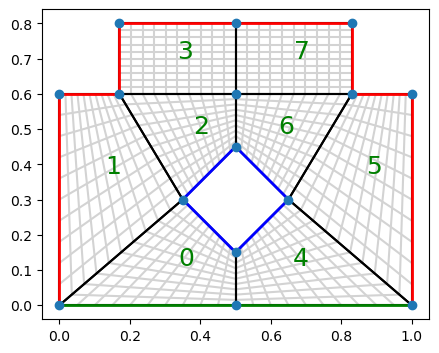

In [7]:
M = ComputerChip(3,10)

# visualize the PatchMesh object with Dirichlet boundary (blue) and Neumann boundary (red)
M.plotmesh(patch_idx = True, knots=True, nodes=True, bcolor={'Dirichlet':'blue','Neumann':'red','Robin':'green'}, bwidth=2)
plt.axis('scaled');

In [8]:
kappa = 130.0
alpha = 0.2
f = lambda x,y: 0.0
gN = lambda x,y: 0.0
gD = lambda x,y: 500.0
gR = lambda x,y: 300.0*alpha
lam = {0:0.01, 1:3.95}

In [9]:
MP = assemble.MultiBasis(M)
MP.set_subspace('C0')

# set Dirichlet values for DoFs at the Dirichlet boundary
dir_bcs = MP.set_dirichlet_boundary({'Dirichlet':gD})

# assemble the linear system and (possible) Neumann vector or Robin matrix/vector
Kh = sum([MP.assemble_volume("lam * inner(grad(u), grad(v)) * dx", arity = 2, domain_id=i, lam=lam[i]) for i in range(2)]) 
Fh = MP.assemble_volume("f * v * dx", arity=1, f=f) #f is living in the physical domain

# generate Neumann vector for global contribution to the right hand side, in this case it is a zero vector since g1 is zero
Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann')

# generate Robin Matrix for global contribution to the right hand side, in this case it is a zero matrix again since alpha is zero
Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Robin')
Nh += MP.assemble_surface('(gR * v) * ds', arity=1, gR=gR, boundary_idx='Robin')

setting up constraints took 0.017815113067626953 seconds.
Basis setup took 0.002893686294555664 seconds


In [10]:
LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
u = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

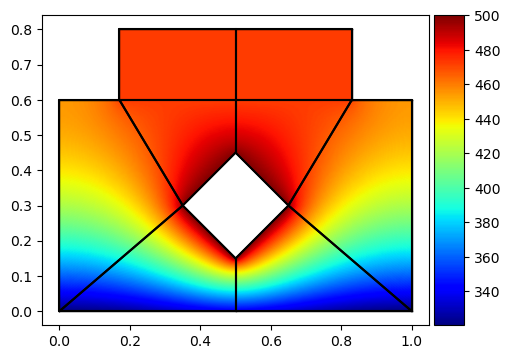

In [11]:
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True, mesh=True);

# Using non-matching multi-patch domains for adaptive refinement

In [12]:
def solveChip(MP, lam, f):
    kappa = 130.0
    alpha = 0.2
    gN = lambda x,y: 0.0
    gD = lambda x,y: 500.0
    gR = lambda x,y: 300.0*alpha

    Kh = sum([MP.assemble_volume("lam * inner(grad(u), grad(v)) * dx", arity = 2, domain_id=i, lam=lam[i]) for i in range(len(lam))])
    Fh = sum([MP.assemble_volume("f * v * dx", arity=1, domain_id = i, f=f[i]) for i in range(2)]) #f is living in the physical domain

    Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann')
    Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Robin')
    Nh += MP.assemble_surface('(gR * v) * ds', arity=1, gR=gR, boundary_idx='Robin')

    LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
    return LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

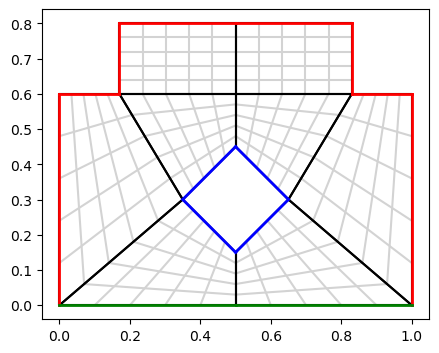

setting up constraints took 0.012872695922851562 seconds.
Basis setup took 0.0019834041595458984 seconds
0.9999999999999997
1.9478426800016015


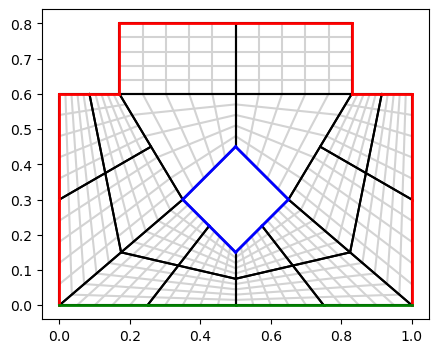

setting up constraints took 0.038216352462768555 seconds.
Basis setup took 0.002287149429321289 seconds
0.02083333333333331
1.2832674392211505


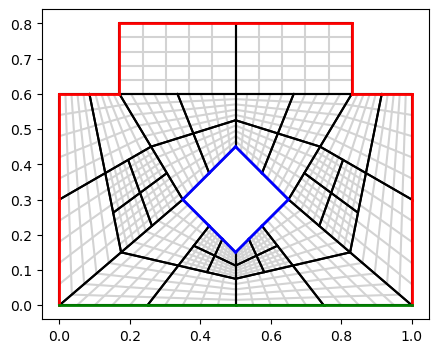

setting up constraints took 0.20779871940612793 seconds.
Basis setup took 0.002721071243286133 seconds
0.020833333333333266
0.8441447929131098


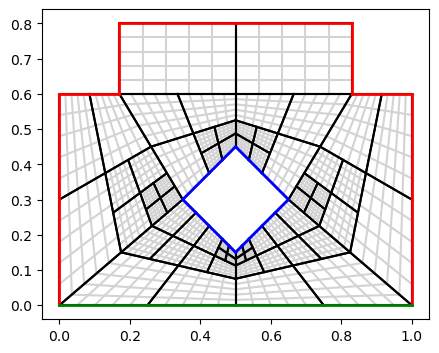

setting up constraints took 0.15926074981689453 seconds.
Basis setup took 0.0034656524658203125 seconds
0.002604166666666664
0.5693794170266177


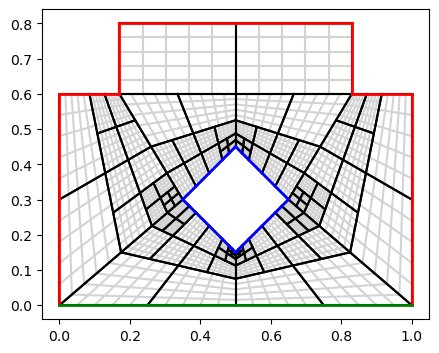

setting up constraints took 0.25707030296325684 seconds.
Basis setup took 0.0041582584381103516 seconds
0.002604166666666664
0.36920909920372635


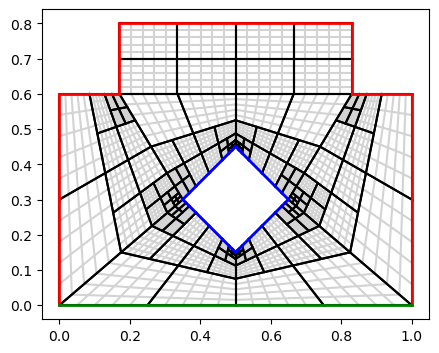

setting up constraints took 0.3634774684906006 seconds.
Basis setup took 0.004920005798339844 seconds
0.002604166666666664
0.233701488883448


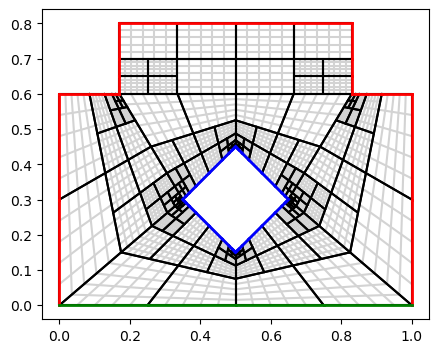

setting up constraints took 0.48491978645324707 seconds.
Basis setup took 0.005545854568481445 seconds
0.0013020833333333435
0.1468837571641089


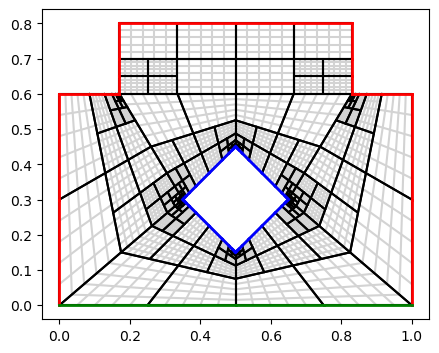

setting up constraints took 0.5813066959381104 seconds.
Basis setup took 0.0068318843841552734 seconds
0.00024414062499999897
0.09457434786546061


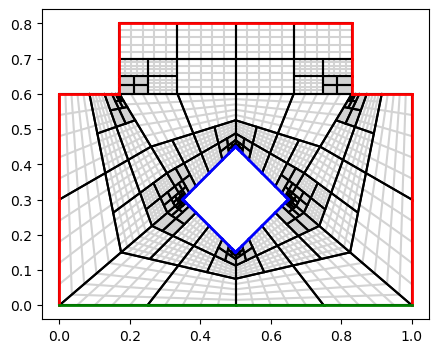

setting up constraints took 0.6982755661010742 seconds.
Basis setup took 0.006863594055175781 seconds
3.051757812500007e-05
0.060480886192825836


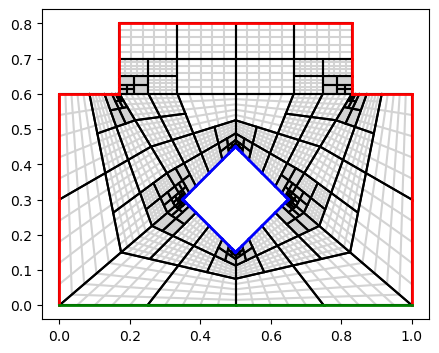

setting up constraints took 0.83721923828125 seconds.
Basis setup took 0.007775783538818359 seconds
3.051757812500058e-05
0.038384351483635094


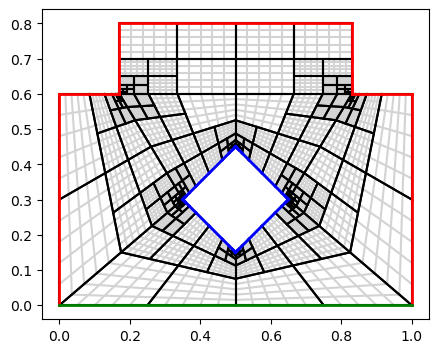

setting up constraints took 0.9641945362091064 seconds.
Basis setup took 0.008788347244262695 seconds
3.0517578124999817e-05
0.024584555742903576


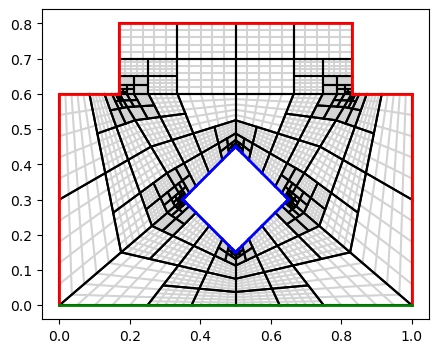

setting up constraints took 1.1072182655334473 seconds.
Basis setup took 0.009690999984741211 seconds
3.051757812499771e-05
0.015492258075541446


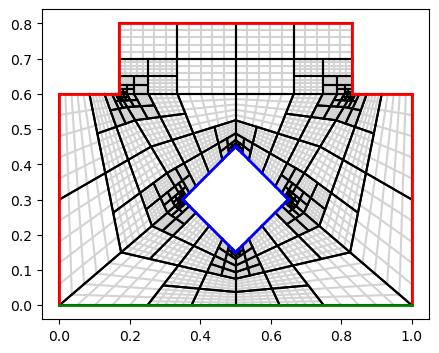

setting up constraints took 1.2606945037841797 seconds.
Basis setup took 0.010772705078125 seconds
3.0517578125000725e-05
0.00987621718878742


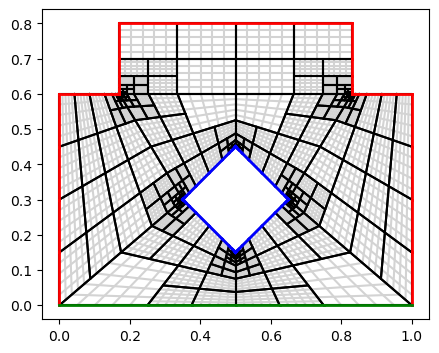

setting up constraints took 1.447526216506958 seconds.
Basis setup took 0.012140989303588867 seconds
3.051757812500921e-05
0.006305537673030581


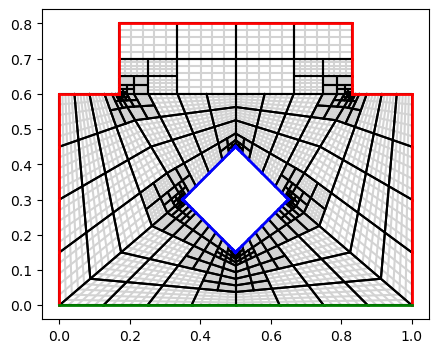

setting up constraints took 1.7574148178100586 seconds.
Basis setup took 0.01398777961730957 seconds
3.05175781249971e-05
0.003974286427623805


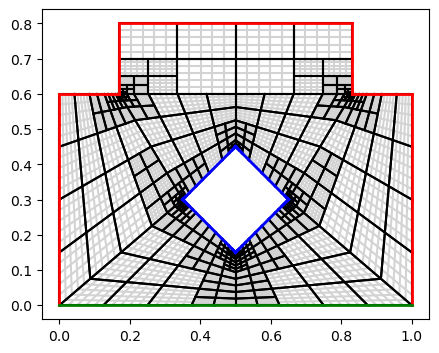

setting up constraints took 2.0492537021636963 seconds.
Basis setup took 0.015675067901611328 seconds
3.051757812496314e-05
0.0025349745357688856


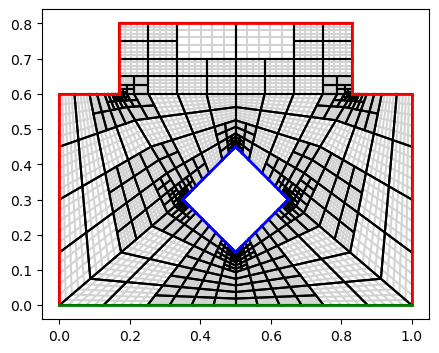

setting up constraints took 2.504011869430542 seconds.
Basis setup took 0.018956899642944336 seconds
1.2833590934101207e-11
0.0015967439759983803


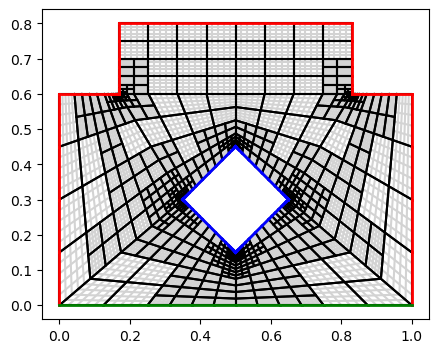

setting up constraints took 3.116670608520508 seconds.
Basis setup took 0.023097991943359375 seconds


AssertionError: Not an H^1-conforming function space.

In [14]:
M = ComputerChip(3,5)

maxiter=20
it=0
lam = {0:3.95, 1:3.95}
f = {0:0., 1:0.}
while True:
    M.plotmesh(figsize=(5,5),patch_idx = False, knots=True, nodes=False, 
               bcolor={'Dirichlet':'blue','Neumann':'red','Robin':'green'}, bwidth=2)
    plt.axis('scaled');
    plt.show()

    MP = assemble.MultiBasis(M)
    MP.set_subspace('C0')

    print(abs(MP.B.data).min())
    
    dir_bcs = MP.set_dirichlet_boundary({'Dirichlet':gD})

    #assemble and solve
    u = solveChip(MP, lam, f)

    #estimate
    err_ind = adaptive.mp_resPois(MP,u,a=lam, f=f)
    eta=np.linalg.norm(err_ind)
    print(eta)
    if eta < 1e-4:
        print("#############################################################")
        print("Terminated successfully after {} iterations".format(it))
        print("#############################################################")
        break
    if it==maxiter:
        print("Iteration hit maximal number of iterations ({}).".format(maxiter))

    #mark
    marked_patches = adaptive.doerfler_mark(err_ind, theta=0.95, TOL=0.05)

    #refine
    M.h_refine(patches=marked_patches,ref="rs");
    it+=1
    
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True);

In [ ]:
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True, mesh=False);

In [22]:
from scipy.sparse.linalg import norm as spnorm

print(spnorm(MP.B@MP.Basis))

3.464101615137981


In [14]:
MP.P2G

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 41550 stored elements and shape (41550, 51062)>

In [16]:
MP.Basis

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 62644 stored elements and shape (51062, 41550)>

In [23]:
MP.P2G@MP.Basis-

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 46257 stored elements and shape (46256, 46256)>

In [24]:
spnorm(MP.P2G@MP.Basis-scipy.sparse.identity(MP.Basis.shape[1]))# <1e-12*np.sqrt(self.Basis.shape[1])

np.float64(1.1719885770250645e-12)

In [26]:
1e-12*np.sqrt(MP.Basis.shape[1])

np.float64(2.1507208094032103e-10)

In [27]:
spnorm

<function scipy.sparse.linalg._norm.norm(x, ord=None, axis=None)>

In [28]:
print(spnorm(MP.B@MP.Basis))

3.464101615137981


In [29]:
1e-12*spnorm(MP.B)*spnorm(MP.Basis)

np.float64(3.231041339560562e-08)

In [33]:
abs(MP.B.data).min()

np.float64(1.083681187309866e-12)